# Elicitation odds ratios — all Othello conversations

Which participant acts summon which assistant acts. One logit per assistant act on all six
participant acts simultaneously, standard errors clustered by participant. The adjustment
matters: participant acts co-occur within a turn, so an unadjusted lift for one act partly
reflects the others.

**Scope.** All five Othello datasets that have conversations — 1274 assistant turns from 243
participants, every one carrying both annotation layers. The two baseline studies are absent
because R1 was unassisted there, so there are no conversations to code.

**Scheme** follows `bad_user_sim/elicitation_analysis.ipynb` exactly, so these sit on one
scale with the existing analysis: the three affective codes collapse to one `Feedback`,
`Comprehension Gauging Question` and `Paraphrase` are dropped, and both are applied to each
seat *before* the majority re-vote. Six assistant codes clear kappa .6 and may carry a claim;
`Hint` (.38) and `Feedback` (.47) are printed and marked `NO` so their absence is visible
rather than silent.

**Separation.** In a 63-turn subset a participant act can perfectly predict an assistant act,
and the MLE then runs to ±∞ — statsmodels happily reports an odds ratio of 1e18. Those cells
print as `sep` and are stored as NaN, so nothing downstream averages an artefact.

**These are observational.** The participant's act is not randomised, so an elicitation
association is not a causal effect. Forcing an act does not reproduce it: in the simulator's
`gate-require_kdq` arm the act was classifier-enforced and the link it was supposed to carry
collapsed from 86% to 47%.

In [33]:
import sys, importlib
sys.path.insert(0, ".")
import numpy as np, pandas as pd

# Reload rather than plain-import: Python caches modules, so editing elicitation.py and
# re-running this cell would otherwise keep calling the OLD load_turns and produce a
# KeyError on any column added since the kernel started.
import elicitation
importlib.reload(elicitation)
from elicitation import load_turns, prevalence, or_table, ALL_A, RELIABLE, SHORT, FOCUS

T = load_turns()
# The three iteration deployments are 63-92 turns each -- too thin to fit on their own
# (most cells separate). Pooled they are 219 turns, which is estimable.
T["group"] = T.source.where(T.source.isin(["phase1_othello", "phase2"]), "iteration_forms")

print(f"{len(T)} assistant turns, {T.pid.nunique()} participants")
print(f"three-seat: {(T.n_seats == 3).sum()} | both layers: {T.has_user_layer.sum()}")
T.groupby(["group", "source", "condition"]).agg(participants=("pid", "nunique"),
                                                turns=("pid", "size"))

1446 assistant turns, 273 participants
three-seat: 1446 | both layers: 1446


participants  \
group           source         condition                                      
iteration_forms 3arm           3arm_johnny_connect_four_boost            13   
                               3arm_vanilla                              17   
                esr            elicit_select_reply                       12   
                johnny         johnny_connect_four_boost                 15   
                modelled_ta    modelled_think_aloud                      16   
phase1_othello  phase1_othello phase1_othello                           120   
phase2          phase2         v2_think_pair                             26   
                               v9_two_rows                               15   
                               vanilla                                   39   

                                                               turns  
group           source         condition                              
iteration_forms 3arm           3arm_johnny_connect_four_boost     74  
                               3arm_vanilla                       98  
                esr            elicit_select_reply                63  
                johnny         johnny_connect_four_boost          64  
                modelled_ta    modelled_think_aloud               92  
phase1_othello  phase1_othello phase1_othello                    667  
phase2          phase2         v2_think_pair                     119  
                               v9_two_rows                        95  
                               vanilla                           174

## What the assistant produces, by source

Share of assistant turns carrying each act.

In [34]:
prevalence(T)

,participants,turns,Board Report,Move Verdict,General Principle,Local Justification,Worked Line,Prompt,Hint,Feedback
3arm,30.0,172.0,39.5,52.9,67.4,75.6,7.0,24.4,21.5,23.8
esr,12.0,63.0,47.6,47.6,52.4,69.8,7.9,19.0,19.0,27.0
johnny,15.0,64.0,39.1,53.1,53.1,70.3,18.8,25.0,20.3,32.8
modelled_ta,16.0,92.0,44.6,31.5,68.5,60.9,9.8,22.8,13.0,25.0
phase1_othello,120.0,667.0,39.7,42.4,59.2,75.3,12.1,30.0,25.8,30.6
phase2,80.0,388.0,47.2,45.6,54.1,66.5,7.7,22.7,22.4,20.6
ALL,273.0,1446.0,42.3,44.5,58.9,71.6,10.3,26.2,23.0,26.7


## Pooled — the headline

Source fixed effects included, so the estimate is not driven by between-study differences in
how often each act happens to occur.

In [35]:
pooled = or_table(T, "ALL OTHELLO CONVERSATIONS", source_fe=True)

ALL OTHELLO CONVERSATIONS — odds ratio for each assistant act, adjusted for all participant acts  [+ source fixed effects]
  273 participants, 1446 assistant turns
assistant act                     ThinkAloud                SolReq                   KDQ  kappa>=.6
Board Report                       0.85                  0.15 ***              1.41             yes
Move Verdict                       0.75                 20.16 ***              0.23 ***         yes
General Principle                  1.29                  0.80                  3.78 ***         yes
Local Justification                1.86 **               6.67 ***              0.62             yes
Worked Line                        1.91 **               0.81                  0.76             yes
Prompt                             2.45 ***              0.24 ***              0.40 ***         yes
Hint                               2.21 ***              0.23 ***              0.36 ***          NO
Feedback                           2

## Adopters vs non-adopters

The population split from `scores_adopter_non_adopter.ipynb`. `phase_othello` recruited
adopters; phase 2 screens for non-adoption and the iteration deployments inherit that screen,
so every other source is non-adopters. Nicely balanced for this question — 667 adopter turns
against 607 non-adopter turns.

The assistant is the same model with the same system prompt in both, so a difference here
means the two populations' acts land differently on the coach, not that the coach differs.

In [36]:
display(T.groupby(["population", "source"]).agg(participants=("pid", "nunique"),
                                                turns=("pid", "size")))

per_pop = {pop: or_table(T[T.population == pop], pop.upper(), bh=False)
           for pop in ["adopters", "non-adopters"]}

participants  turns
population   source                             
adopters     phase1_othello           120    667
non-adopters 3arm                      30    172
             esr                       12     63
             johnny                    15     64
             modelled_ta               16     92
             phase2                    80    388

ADOPTERS — odds ratio for each assistant act, adjusted for all participant acts
  120 participants, 667 assistant turns
assistant act                     ThinkAloud                SolReq                   KDQ  kappa>=.6
Board Report                       0.98                  0.17 ***              1.55             yes
Move Verdict                       0.72                 33.51 ***              0.11 ***         yes
General Principle                  1.00                  0.56 *                3.86 ***         yes
Local Justification                1.71                  7.71 ***              0.64             yes
Worked Line                        2.26 **               0.82                  0.63             yes
Prompt                             2.13 ***              0.15 ***              0.43 **          yes
Hint                               1.68 *                0.16 ***              0.42 *            NO
Feedback                           2.54 ***              0.28 ***              0

/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Side by side

Both columns are well powered, so a gap here is more trustworthy than the arm split below.

In [37]:
rows = []
for aa in [a for a in ALL_A if a in RELIABLE]:
    for pa in FOCUS:
        k = SHORT[pa]
        ad = per_pop["adopters"].get((aa, k), (np.nan,))[0]
        na = per_pop["non-adopters"].get((aa, k), (np.nan,))[0]
        rows.append({"assistant act": aa, "participant act": k,
                     "adopters": ad, "non-adopters": na,
                     "same side of 1": ("-" if (np.isnan(ad) or np.isnan(na))
                                        else "yes" if (ad > 1) == (na > 1) else "NO")})

pd.DataFrame(rows).set_index(["assistant act", "participant act"]).round(2)

adopters  non-adopters same side of 1
assistant act       participant act                                       
Board Report        ThinkAloud           0.98          0.73            yes
                    SolReq               0.17          0.13            yes
                    KDQ                  1.55          1.25            yes
Move Verdict        ThinkAloud           0.72          0.76            yes
                    SolReq              33.51         14.27            yes
                    KDQ                  0.11          0.30            yes
General Principle   ThinkAloud           1.00          1.60            yes
                    SolReq               0.56          1.07             NO
                    KDQ                  3.86          3.91            yes
Local Justification ThinkAloud           1.71          1.95            yes
                    SolReq               7.71          6.39            yes
                    KDQ                  0.64          0.58            yes
Worked Line         ThinkAloud           2.26           NaN              -
                    SolReq               0.82           NaN              -
                    KDQ                  0.63           NaN              -
Prompt              ThinkAloud           2.13          2.93            yes
                    SolReq               0.15          0.41            yes
                    KDQ                  0.43          0.38            yes

## Elicitation matrix, drawn — adopters vs non-adopters

The drawing code is ported verbatim from `bad_user_sim/elicitation_analysis.ipynb`
(`elicitation_plot.py`), so these are directly comparable with the figures already there
rather than lookalikes. Same four panels — the assistant acts clearing kappa .60 on every
source — same axis limits, colours, caret and separation handling.

Position relative to the OR = 1 line carries the direction, so colour is redundant with it
and only marks significance. A caret means the interval runs past the axis, not that it
ends there.

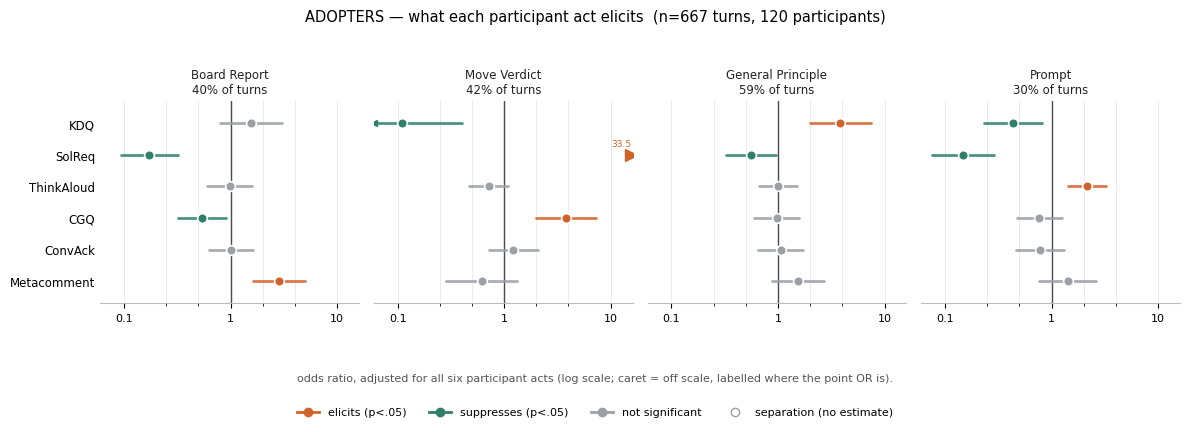

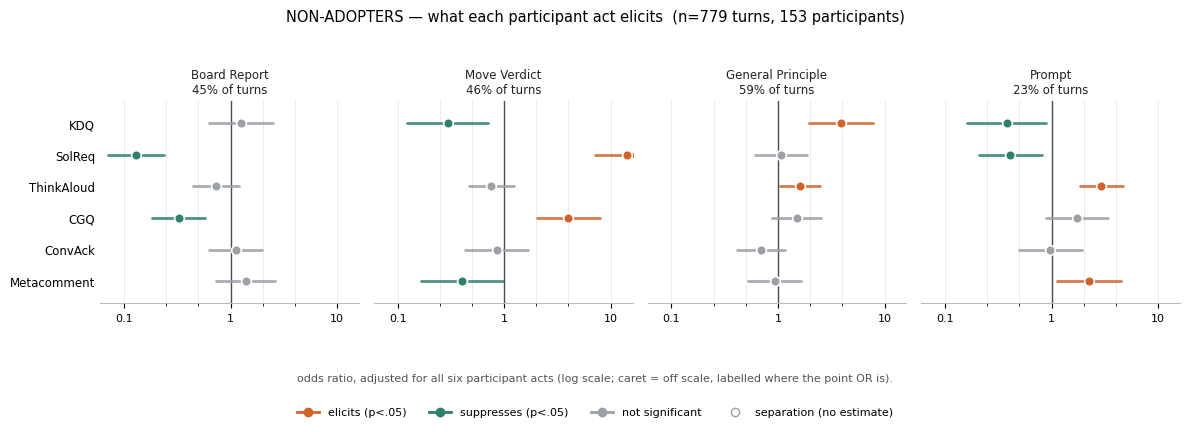

In [38]:
import elicitation_plot
importlib.reload(elicitation_plot)
from elicitation_plot import plot_elicitation

elic_mats = {}
for pop in ["adopters", "non-adopters"]:
    elic_mats[pop] = plot_elicitation(T[T.population == pop], pop)

### The two matrices side by side

Reading the two figures together: the direction agrees nearly everywhere, and the
interaction tests below confirm no cell survives correction for a population difference.

In [39]:
cmp = (pd.concat({p: m.set_index(["asst", "pact"])[["OR", "p"]]
                  for p, m in elic_mats.items()}, axis=1)
         .round(3))
cmp.columns = [f"{p} {c}" for p, c in cmp.columns]
cmp["same side of 1"] = [
    "-" if (np.isnan(a) or np.isnan(b)) else ("yes" if (a > 1) == (b > 1) else "NO")
    for a, b in zip(cmp.iloc[:, 0], cmp.iloc[:, 2])]
cmp

adopters OR  adopters p  non-adopters OR  \
asst              pact                                                    
Board Report      KDQ                1.553       0.198            1.249   
                  SolReq             0.173       0.000            0.129   
                  ThinkAloud         0.982       0.942            0.728   
                  CGQ                0.540       0.022            0.327   
                  ConvAck            1.015       0.951            1.116   
                  Metacomment        2.849       0.000            1.391   
Move Verdict      KDQ                0.110       0.001            0.296   
                  SolReq            33.511       0.000           14.266   
                  ThinkAloud         0.716       0.121            0.759   
                  CGQ                3.815       0.000            3.992   
                  ConvAck            1.221       0.464            0.848   
                  Metacomment        0.614       0.210            0.403   
General Principle KDQ                3.860       0.000            3.913   
                  SolReq             0.561       0.034            1.070   
                  ThinkAloud         1.005       0.982            1.604   
                  CGQ                0.971       0.903            1.501   
                  ConvAck            1.060       0.814            0.691   
                  Metacomment        1.530       0.138            0.932   
Prompt            KDQ                0.434       0.010            0.379   
                  SolReq             0.148       0.000            0.410   
                  ThinkAloud         2.133       0.000            2.931   
                  CGQ                0.767       0.288            1.733   
                  ConvAck            0.774       0.330            0.974   
                  Metacomment        1.412       0.266            2.258   

                               non-adopters p same side of 1  
asst              pact                                        
Board Report      KDQ                   0.527            yes  
                  SolReq                0.000            yes  
                  ThinkAloud            0.212            yes  
                  CGQ                   0.000            yes  
                  ConvAck               0.710            yes  
                  Metacomment           0.311            yes  
Move Verdict      KDQ                   0.006            yes  
                  SolReq                0.000            yes  
                  ThinkAloud            0.273            yes  
                  CGQ                   0.000            yes  
                  ConvAck               0.630             NO  
                  Metacomment           0.044            yes  
General Principle KDQ                   0.000            yes  
                  SolReq                0.814             NO  
                  ThinkAloud            0.030            yes  
                  CGQ                   0.137             NO  
                  ConvAck               0.157             NO  
                  Metacomment           0.811             NO  
Prompt            KDQ                   0.025            yes  
                  SolReq                0.011            yes  
                  ThinkAloud            0.000            yes  
                  CGQ                   0.107             NO  
                  ConvAck               0.939            yes  
                  Metacomment           0.021            yes

## By group

The two large studies are powered on their own. The iteration forms are pooled; even so a few
cells separate.

In [40]:
per_group = {}
for grp in ["phase1_othello", "phase2", "iteration_forms"]:
    per_group[grp] = or_table(T[T.group == grp], grp.upper(), bh=False)

PHASE1_OTHELLO — odds ratio for each assistant act, adjusted for all participant acts
  120 participants, 667 assistant turns
assistant act                     ThinkAloud                SolReq                   KDQ  kappa>=.6
Board Report                       0.98                  0.17 ***              1.55             yes
Move Verdict                       0.72                 33.51 ***              0.11 ***         yes
General Principle                  1.00                  0.56 *                3.86 ***         yes
Local Justification                1.71                  7.71 ***              0.64             yes
Worked Line                        2.26 **               0.82                  0.63             yes
Prompt                             2.13 ***              0.15 ***              0.43 **          yes
Hint                               1.68 *                0.16 ***              0.42 *            NO
Feedback                           2.54 ***              0.28 ***         

/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Phase 2 split by arm

The elicitation model answers "what does the assistant do in response to this act", and the
assistant is identical across phase-2 arms — same model, byte-identical system prompt. So a
difference between arms here would mean the arms' acts *mean* something different to the
coach, not that the coach changed. Worth checking precisely because the intervention was
designed to change how people talk.

`intervened` pools v2_think_pair and v9_two_rows; separately they are 119 and 95 turns, thin
enough that most cells separate.

In [41]:
p2 = T[T.source == "phase2"].copy()
p2["arm"] = np.where(p2.condition == "vanilla", "vanilla", "intervened")
display(p2.groupby(["arm", "condition"]).agg(participants=("pid", "nunique"),
                                             turns=("pid", "size")))

per_arm = {arm: or_table(p2[p2.arm == arm], f"PHASE 2 — {arm.upper()}", bh=False)
           for arm in ["vanilla", "intervened"]}

participants  turns
arm        condition                         
intervened v2_think_pair            26    119
           v9_two_rows              15     95
vanilla    vanilla                  39    174

PHASE 2 — VANILLA — odds ratio for each assistant act, adjusted for all participant acts
  39 participants, 174 assistant turns
assistant act                     ThinkAloud                SolReq                   KDQ  kappa>=.6
Board Report                       0.63                  0.05 **               1.25             yes
Move Verdict                       0.25 **               5.87 *                0.06 **          yes
General Principle                  2.40                  1.60                  3.36             yes
Local Justification                1.59                  7.27 *                0.44             yes
Worked Line                         sep                   sep                   sep             yes
Prompt                             8.30 ***              0.54                  1.49             yes
Hint                               4.44 **               0.37                  1.05              NO
Feedback                           1.45                  0.05 *         

/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Do the two arms elicit the same way?

Same caution as everywhere else in this notebook: 174 and 214 turns, so read the direction
and the ordering, not the second digit.

In [42]:
rows = []
for aa in [a for a in ALL_A if a in RELIABLE]:
    for pa in FOCUS:
        k = SHORT[pa]
        v = per_arm["vanilla"].get((aa, k), (np.nan,))[0]
        s = per_arm["intervened"].get((aa, k), (np.nan,))[0]
        rows.append({"assistant act": aa, "participant act": k,
                     "vanilla": v, "intervened": s,
                     "same side of 1": ("-" if (np.isnan(v) or np.isnan(s))
                                        else "yes" if (v > 1) == (s > 1) else "NO")})

pd.DataFrame(rows).set_index(["assistant act", "participant act"]).round(2)

vanilla  intervened same side of 1
assistant act       participant act                                    
Board Report        ThinkAloud          0.63        0.88            yes
                    SolReq              0.05        0.16            yes
                    KDQ                 1.25        1.39            yes
Move Verdict        ThinkAloud          0.25        0.94            yes
                    SolReq              5.87       14.34            yes
                    KDQ                 0.06        0.75            yes
General Principle   ThinkAloud          2.40        0.89             NO
                    SolReq              1.60        0.64             NO
                    KDQ                 3.36        1.49            yes
Local Justification ThinkAloud          1.59        3.80            yes
                    SolReq              7.27        6.31            yes
                    KDQ                 0.44        0.57            yes
Worked Line         ThinkAloud           NaN         NaN              -
                    SolReq               NaN         NaN              -
                    KDQ                  NaN         NaN              -
Prompt              ThinkAloud          8.30        3.81            yes
                    SolReq              0.54        0.59            yes
                    KDQ                 1.49        0.18             NO

## Does the direction replicate? (reliable acts only)

In [43]:
rows = []
for aa in [a for a in ALL_A if a in RELIABLE]:
    for pa in FOCUS:
        k = SHORT[pa]
        po = pooled.get((aa, k), (np.nan,))[0]
        cell = {"assistant act": aa, "participant act": k, "pooled OR": po}
        agree = 0, 0
        for grp, res in per_group.items():
            o = res.get((aa, k), (np.nan,))[0]
            cell[grp] = o
            if not np.isnan(o) and not np.isnan(po):
                agree = agree[0] + int((o > 1) == (po > 1)), agree[1] + 1
        cell["same side of 1"] = f"{agree[0]}/{agree[1]}" if agree[1] else "-"
        rows.append(cell)

pd.DataFrame(rows).set_index(["assistant act", "participant act"]).round(2)

pooled OR  phase1_othello  phase2  \
assistant act       participant act                                      
Board Report        ThinkAloud            0.85            0.98    0.79   
                    SolReq                0.15            0.17    0.11   
                    KDQ                   1.41            1.55    1.51   
Move Verdict        ThinkAloud            0.75            0.72    0.56   
                    SolReq               20.16           33.51    9.88   
                    KDQ                   0.23            0.11    0.25   
General Principle   ThinkAloud            1.29            1.00    1.37   
                    SolReq                0.80            0.56    0.99   
                    KDQ                   3.78            3.86    2.17   
Local Justification ThinkAloud            1.86            1.71    2.53   
                    SolReq                6.67            7.71    6.32   
                    KDQ                   0.62            0.64    0.44   
Worked Line         ThinkAloud            1.91            2.26     NaN   
                    SolReq                0.81            0.82     NaN   
                    KDQ                   0.76            0.63     NaN   
Prompt              ThinkAloud            2.45            2.13    4.44   
                    SolReq                0.24            0.15    0.53   
                    KDQ                   0.40            0.43    0.64   

                                     iteration_forms same side of 1  
assistant act       participant act                                  
Board Report        ThinkAloud                  0.67            3/3  
                    SolReq                      0.16            3/3  
                    KDQ                         1.16            3/3  
Move Verdict        ThinkAloud                  1.03            2/3  
                    SolReq                     23.51            3/3  
                    KDQ                         0.37            3/3  
General Principle   ThinkAloud                  1.82            3/3  
                    SolReq                      1.04            2/3  
                    KDQ                         8.59            3/3  
Local Justification ThinkAloud                  1.53            3/3  
                    SolReq                      6.54            3/3  
                    KDQ                         0.70            3/3  
Worked Line         ThinkAloud                   NaN            1/1  
                    SolReq                       NaN            1/1  
                    KDQ                          NaN            1/1  
Prompt              ThinkAloud                  1.96            3/3  
                    SolReq                      0.30            3/3  
                    KDQ                         0.21            3/3

## Board Report — the load-bearing row

Board Report is the assistant act that predicted transfer in phase 1. If Think Aloud does not
elicit it, then Think Aloud's transfer association cannot run *through* the assistant — even
though Think Aloud visibly changes what the assistant does otherwise (Prompt, Worked Line,
Local Justification all move).

In [44]:
pd.DataFrame({SHORT[pa]: {"odds ratio": round(pooled[("Board Report", SHORT[pa])][0], 2),
                          "p": round(pooled[("Board Report", SHORT[pa])][1], 4)}
              for pa in FOCUS}).T

,odds ratio,p
ThinkAloud,0.85,0.3416
SolReq,0.15,0.0000
KDQ,1.41,0.1434
